# Imports

In [25]:
import os 
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)


## Data loading and preparation

In [4]:
train_dir = "train"
test_dir = "test"

IMG_SIZE = (48, 48)
BATCH_SIZE = 64

train_data = keras.utils.image_dataset_from_directory(
    train_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_data = keras.utils.image_dataset_from_directory(
    train_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42
)

test_data = keras.utils.image_dataset_from_directory(
    test_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_data.class_names
print("Class names:", class_names)

normalization_layer = layers.Rescaling(1./255)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [19]:
# Limits dataset for faster training
train_dataset = train_data #.take(250)
val_dataset = val_data #.take(60)
#test_dataset = test_data

Training pictures per class:
angry: 3995 pictures
disgust: 436 pictures
fear: 4097 pictures
happy: 7215 pictures
neutral: 4965 pictures
sad: 4830 pictures
surprise: 3171 pictures


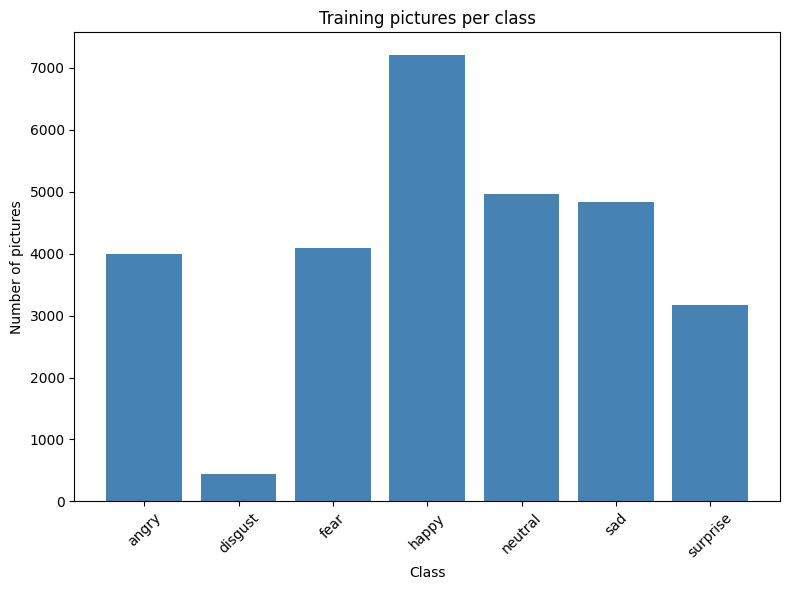

In [6]:
# Counts picrures per class in training set

print("Training pictures per class:")
count = {}
for c in class_names:
    antal = len(os.listdir(os.path.join(train_dir, c)))
    count[c] = antal
    print(f"{c}: {antal} pictures")

# Fördelning av klass

plt.figure(figsize=(8, 6))
plt.bar(count.keys(), count.values(), color='steelblue')
plt.title('Training pictures per class')
plt.ylabel('Number of pictures')
plt.xlabel('Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

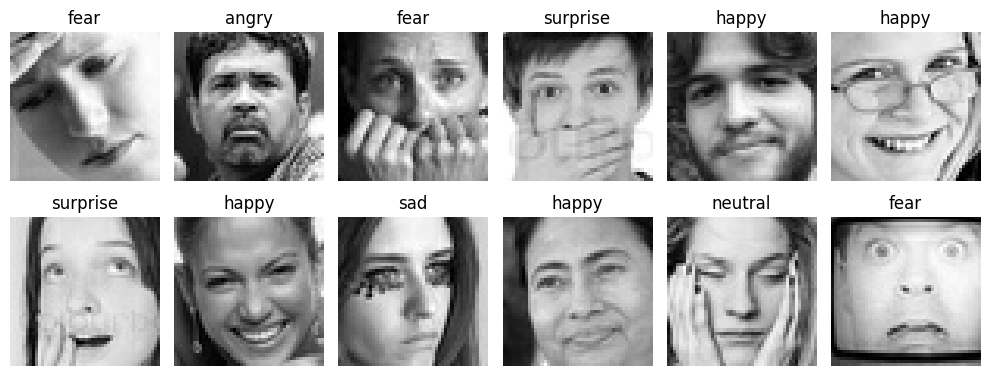

In [7]:
# Visualizes images from training set
plt.figure(figsize=(10, 4))

for images, labels in train_data.take(1):
    for i in range(12):
        plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.title(class_names[labels[i]])
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

In [18]:
# Builds the CNN model
model = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),
    normalization_layer,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,047 (3.20 MB)

 Trainable params: 839,047 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

## Training

In [16]:
# Early stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

In [20]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=25,
    callbacks=[early_stopping]
)

Epoch 1/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.3214 - loss: 1.7060 - val_accuracy: 0.4024 - val_loss: 1.5471
Epoch 2/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.4134 - loss: 1.5248 - val_accuracy: 0.4510 - val_loss: 1.4398
Epoch 3/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.4525 - loss: 1.4371 - val_accuracy: 0.4722 - val_loss: 1.3846
Epoch 4/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.4742 - loss: 1.3694 - val_accuracy: 0.4830 - val_loss: 1.3434
Epoch 5/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.4968 - loss: 1.3149 - val_accuracy: 0.4849 - val_loss: 1.3307
Epoch 6/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.5157 - loss: 1.2694 - val_accuracy: 0.4914 - val_loss: 1.3120
Epoch 7/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.5330 - loss: 1.2182 - val_accuracy: 0.5083 - val_loss: 1.2917
Epoch 8/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.5504 - loss: 1.1754 - val_acc

In [ ]:
# Training accuracy and loss
test_loss, test_acc = model.evaluate(test_data)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.5173 - loss: 1.2513
Test accuracy: 0.5173
Test loss: 1.2513


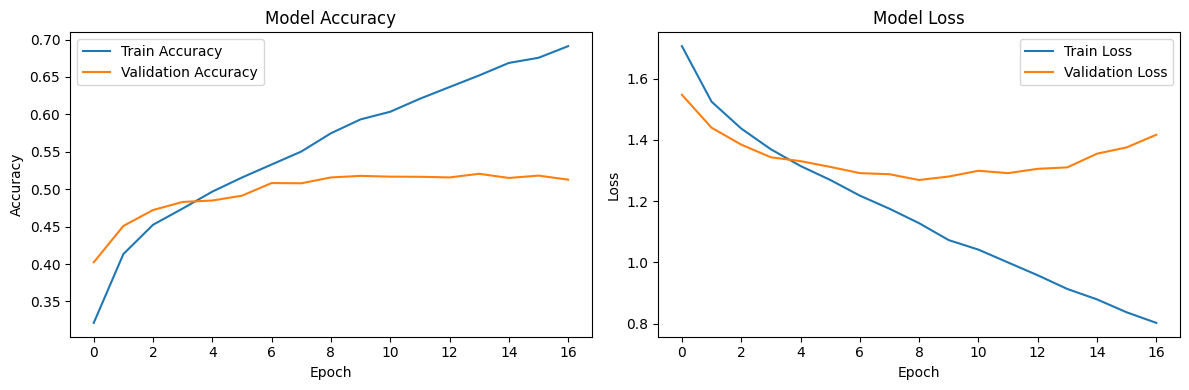

In [ ]:
# Visualizes training accuracy and loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


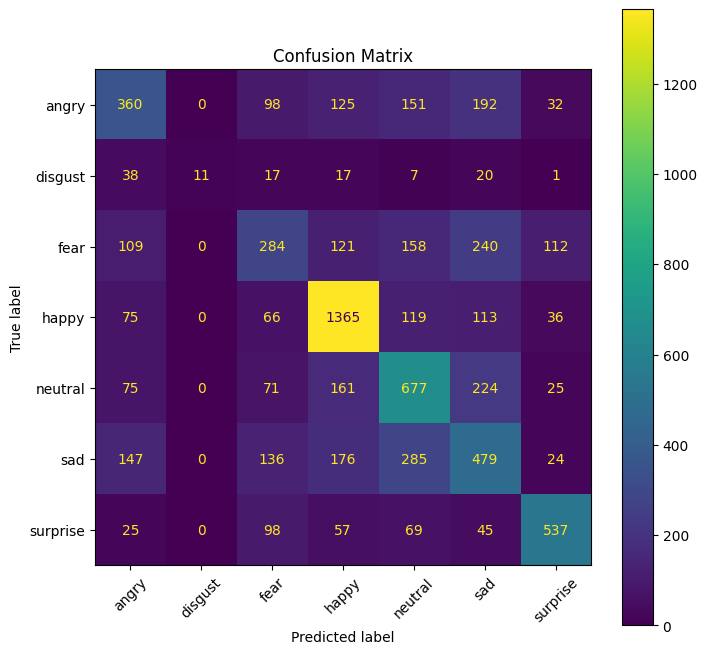

In [29]:
# Confusion matrix
y_true = np.concatenate([y for x, y in test_data], axis=0)
y_pred_probs = model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()